# Onco-Consensus: Multi-Agent Diagnostic Reasoning for Breast Cancer Pathology

**CS505 — Spring 2026**

Three LLM agents (Gemini Flash, Groq/Llama3, Ollama/Llama3) independently analyze FNA biopsy data, debate over 3 rounds, and a Gemini meta-synthesizer produces the final consensus diagnosis.

---

## §0 Setup & Installs

In [1]:
import subprocess
subprocess.run(
    ["pip", "install", "-q",
     "openai", "python-dotenv",
     "pydantic", "scikit-learn", "matplotlib", "seaborn", "pandas", "requests"],
    check=True,
)
print("Installation complete")

Installation complete



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import sys
sys.path.insert(0, os.getcwd())  # ensure src/ is importable

from dotenv import load_dotenv
load_dotenv()

openrouter_ok = bool(os.environ.get('OPENROUTER_API_KEY'))
print(f'OPENROUTER_API_KEY: {"✓ loaded" if openrouter_ok else "✗ missing — add to .env"}')
print('Ollama:             local (no key needed)')

OPENROUTER_API_KEY: ✓ loaded
Ollama:             local (no key needed)


---

## §1 Data Layer

UCI Wisconsin Breast Cancer dataset loaded via scikit-learn. A `case_to_narrative()` function converts 30 FNA nuclear morphology features into a clinical pathology paragraph. Ground-truth labels are hidden from agents.

In [3]:
from src.data_layer import select_cases

cases = select_cases(n_malignant=3, n_benign=2)
print(f'Selected {len(cases)} cases\n')
for c in cases:
    print(f'--- {c.case_id}  (GT: {c.ground_truth}) ---')
    print(c.narrative[:220] + '...\n')

Selected 5 cases

--- CASE-000  (GT: Malignant) ---
Fine needle aspirate (FNA) biopsy of a breast mass. Nuclear morphology: mean radius 17.99 μm (worst 25.38 μm), mean texture 10.38 (worst 17.33), mean perimeter 122.80 μm (worst 184.60 μm), mean area 1001.00 μm² (worst 20...

--- CASE-001  (GT: Malignant) ---
Fine needle aspirate (FNA) biopsy of a breast mass. Nuclear morphology: mean radius 20.57 μm (worst 24.99 μm), mean texture 17.77 (worst 23.41), mean perimeter 132.90 μm (worst 158.80 μm), mean area 1326.00 μm² (worst 19...

--- CASE-002  (GT: Malignant) ---
Fine needle aspirate (FNA) biopsy of a breast mass. Nuclear morphology: mean radius 19.69 μm (worst 23.57 μm), mean texture 21.25 (worst 25.53), mean perimeter 130.00 μm (worst 152.50 μm), mean area 1203.00 μm² (worst 17...

--- CASE-019  (GT: Benign) ---
Fine needle aspirate (FNA) biopsy of a breast mass. Nuclear morphology: mean radius 13.54 μm (worst 15.11 μm), mean texture 14.36 (worst 19.26), mean perimeter 87.46 μm (wors

---

## §2 Structured Data Models

All agent outputs and orchestrator outputs use Pydantic models for reliable parsing.

In [4]:
from src.models import DiagnosisOutput, DebateTranscript, ConsensusReport
print('DiagnosisOutput fields:', list(DiagnosisOutput.model_fields.keys()))
print('DebateTranscript fields:', list(DebateTranscript.model_fields.keys()))
print('ConsensusReport fields:', list(ConsensusReport.model_fields.keys()))

DiagnosisOutput fields: ['agent_name', 'round', 'diagnosis', 'confidence', 'key_findings', 'reasoning', 'changed_opinion']
DebateTranscript fields: ['case_id', 'rounds', 'ground_truth']
ConsensusReport fields: ['case_id', 'final_diagnosis', 'confidence_score', 'rationale', 'dissent_notes', 'correct']


---

## §3 Diagnostic Agents

Three agents, each backed by a different LLM. All receive **identical** input in Round 0. In Rounds 1–2 they see the other agents' prior reasoning.

In [5]:
from src.agents import GeminiAgent, GroqAgent, OllamaAgent

gemini_agent = GeminiAgent()   # OpenRouter → google/gemini-flash-1.5
groq_agent   = GroqAgent()     # OpenRouter → mistralai/mistral-7b-instruct
ollama_agent = OllamaAgent()   # local Ollama, llama3:8b
agents = [gemini_agent, groq_agent, ollama_agent]
print('Agents initialized:')
for a in agents:
    print(f'  • {a.name}')

Agents initialized:
  • GeminiAgent
  • GroqAgent
  • OllamaAgent


---

## §4 Debate Orchestrator + Meta-Synthesizer

- `DebateOrchestrator`: runs 3 rounds of debate, collecting all `DiagnosisOutput` objects into a `DebateTranscript`.
- `MetaSynthesizer`: Gemini in 'chief pathologist' mode synthesizes the full transcript into a `ConsensusReport`.

In [6]:
from src.orchestrator import DebateOrchestrator, MetaSynthesizer

orchestrator = DebateOrchestrator(agents)
synthesizer  = MetaSynthesizer()
print('DebateOrchestrator: 3-round structured debate')
print('MetaSynthesizer:    Gemini in chief-pathologist role')

DebateOrchestrator: 3-round structured debate
MetaSynthesizer:    Gemini in chief-pathologist role


---

## §5 Run Full Pipeline

For each of 5 selected cases: 3-round debate → meta-synthesis → consensus report.

In [7]:
transcripts = []
reports     = []

for case in cases:
    print(f'\n' + '='*55)
    print(f'Processing {case.case_id}  (hidden GT: {case.ground_truth})')
    print('='*55)

    transcript = orchestrator.run(case, num_rounds=3)
    transcripts.append(transcript)

    for r_idx, round_ops in enumerate(transcript.rounds):
        row = '  |  '.join(f'{op.agent_name.replace("Agent","")}: {op.diagnosis[0]} {op.confidence:.2f}'
                           for op in round_ops)
        flips = sum(op.changed_opinion for op in round_ops)
        print(f'  Round {r_idx}: {row}  [{flips} flip(s)]')

    report = synthesizer.synthesize(transcript)
    reports.append(report)
    verdict = '✓ CORRECT' if report.correct else '✗ WRONG'
    print(f'  Consensus: {report.final_diagnosis} (conf: {report.confidence_score:.2f}) — {verdict}')

accuracy = sum(r.correct for r in reports) / len(reports)
print(f'\nOverall accuracy: {accuracy:.0%} ({sum(r.correct for r in reports)}/{len(reports)})')


Processing CASE-000  (hidden GT: Malignant)
  Round 0: Gemini: M 0.95  |  Groq: M 0.80  |  Ollama: B 0.80  [0 flip(s)]
  Round 1: Gemini: M 0.85  |  Groq: M 0.92  |  Ollama: M 0.97  [1 flip(s)]
  Round 2: Gemini: M 0.95  |  Groq: M 0.92  |  Ollama: M 0.89  [0 flip(s)]
  Consensus: Malignant (conf: 0.95) — ✓ CORRECT

Processing CASE-001  (hidden GT: Malignant)
  Round 0: Gemini: M 0.95  |  Groq: M 0.80  |  Ollama: B 0.80  [0 flip(s)]
  Round 1: Gemini: M 0.85  |  Groq: M 0.92  |  Ollama: M 0.95  [1 flip(s)]
  Round 2: Gemini: M 0.95  |  Groq: M 0.92  |  Ollama: M 0.89  [0 flip(s)]
  Consensus: Malignant (conf: 0.95) — ✓ CORRECT

Processing CASE-002  (hidden GT: Malignant)
  Round 0: Gemini: M 0.95  |  Groq: M 0.80  |  Ollama: M 0.80  [0 flip(s)]
  Round 1: Gemini: M 0.95  |  Groq: M 0.97  |  Ollama: M 0.93  [0 flip(s)]
  Round 2: Gemini: M 0.98  |  Groq: M 0.96  |  Ollama: M 0.96  [0 flip(s)]
  Consensus: Malignant (conf: 0.97) — ✓ CORRECT

Processing CASE-019  (hidden GT: Benign)
  Ro

---

## §6 Analytics

Four visualizations:
1. Opinion evolution (did any agent flip?)
2. Agreement heatmap (consensus formation per round)
3. Confidence bar chart (Round 0 vs Round 2)
4. Consensus summary cards

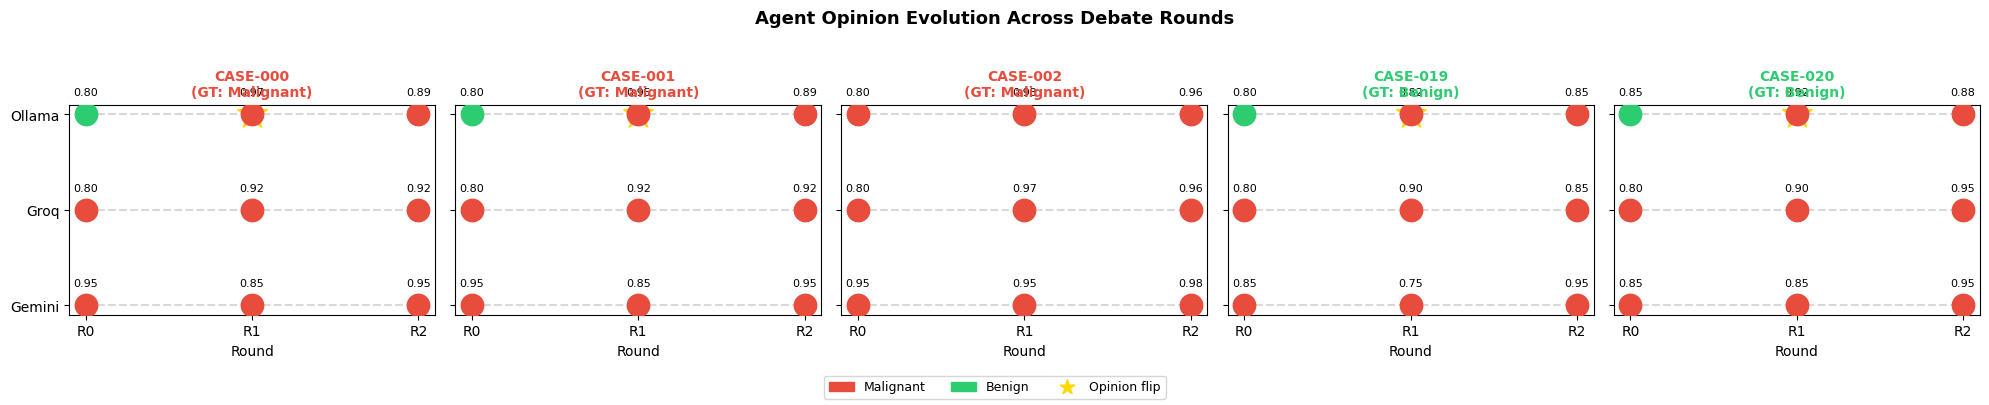

In [8]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from src.analytics import (
    plot_opinion_evolution,
    plot_agreement_heatmap,
    plot_confidence_comparison,
    plot_consensus_summary,
)

plot_opinion_evolution(transcripts)

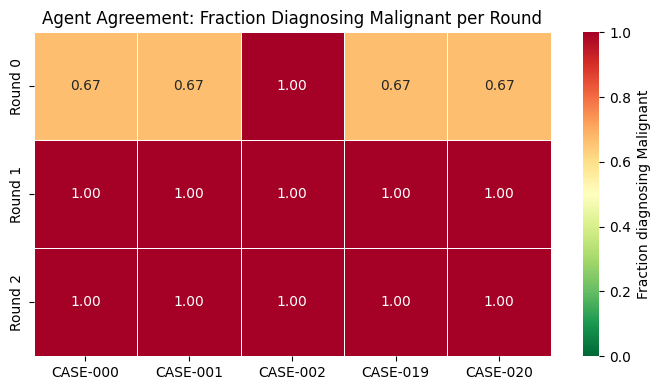

In [9]:
plot_agreement_heatmap(transcripts)

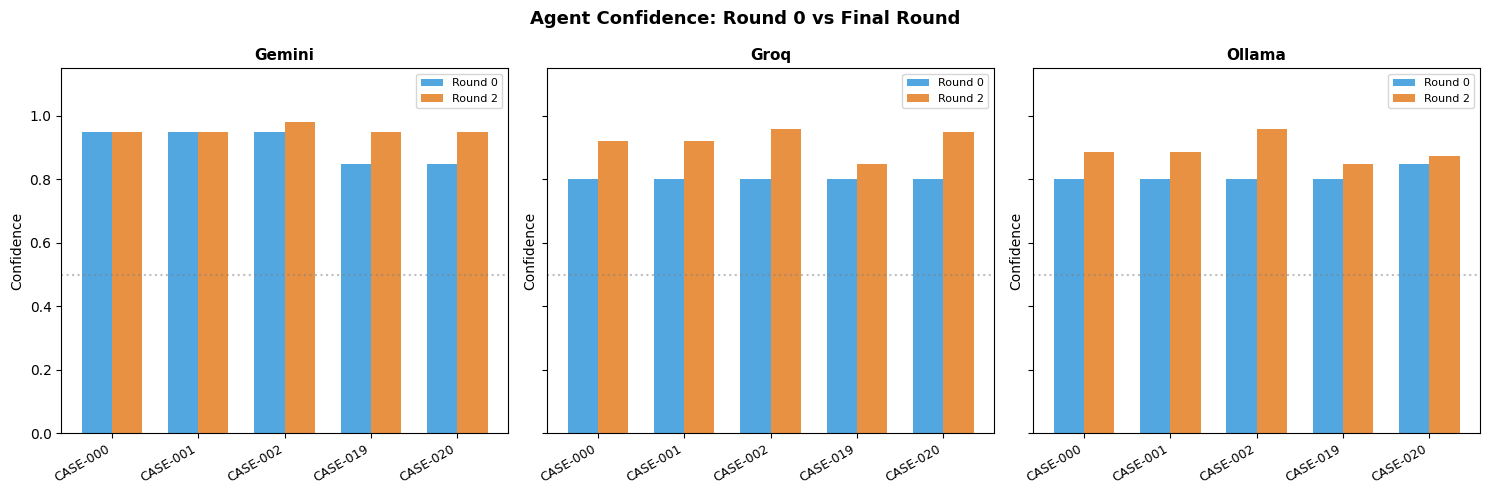

In [10]:
plot_confidence_comparison(transcripts)

/Users/krishna/Library/CloudStorage/OneDrive-SoutheastMissouriStateUniversity/All assignments/Masters/Spring 26/CS505/Onco-Consensus/src/analytics.py:137: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


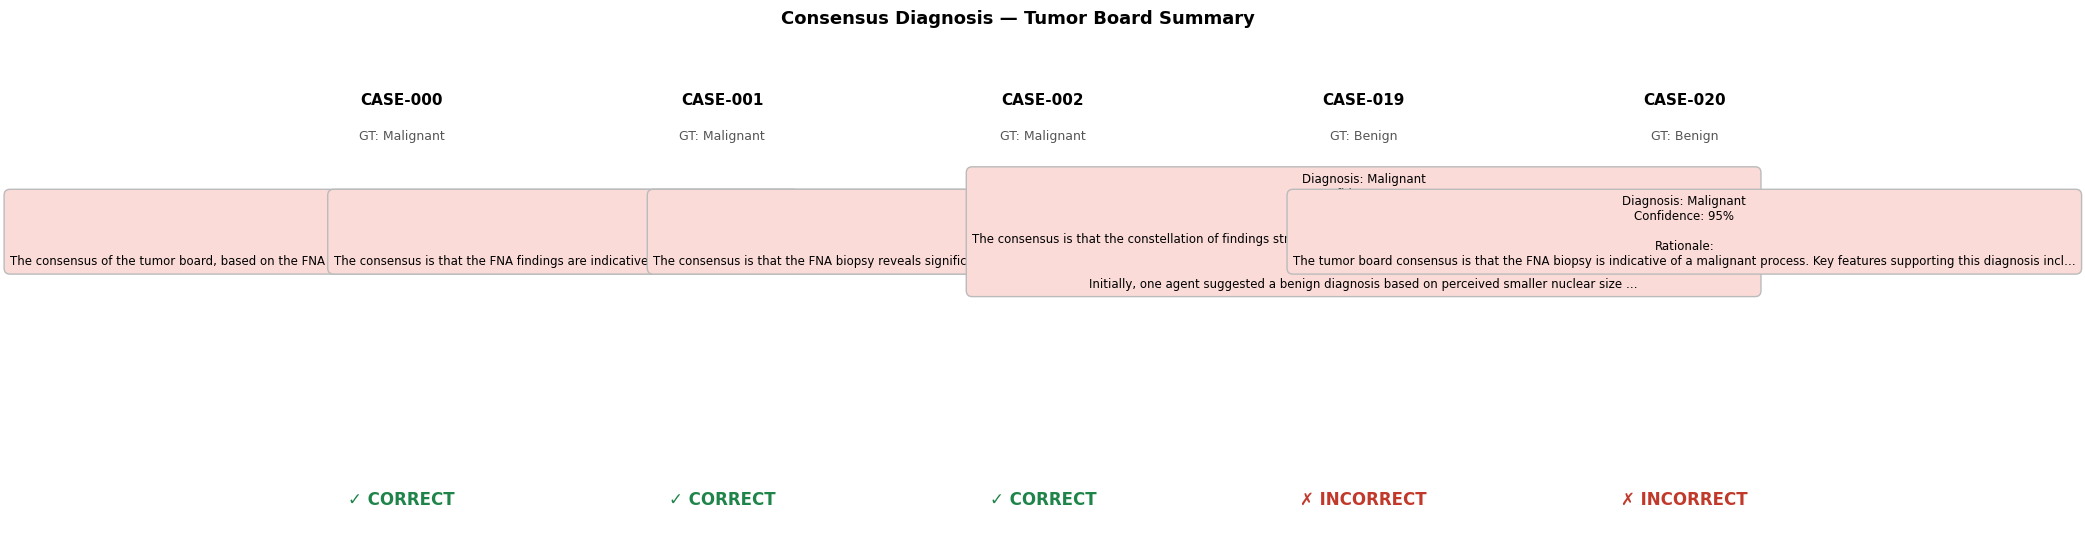

In [11]:
plot_consensus_summary(reports, transcripts)

---

## §7 Results Summary

In [12]:
import pandas as pd
from IPython.display import display

rows = []
for report, t in zip(reports, transcripts):
    row = {'Case': report.case_id, 'Ground Truth': t.ground_truth}
    for a_idx in range(len(t.rounds[0])):
        aname = t.rounds[0][a_idx].agent_name.replace('Agent', '')
        for r_idx in range(len(t.rounds)):
            op = t.rounds[r_idx][a_idx]
            row[aname + ' R' + str(r_idx)] = op.diagnosis[0] + ' ' + f'{op.confidence:.2f}'
    row['Consensus']  = report.final_diagnosis
    row['Confidence'] = f'{report.confidence_score:.2f}'
    row['Correct']    = '\u2713' if report.correct else '\u2717'
    rows.append(row)

df = pd.DataFrame(rows).set_index('Case')
display(df)
print(f'\nAccuracy: {sum(r.correct for r in reports)}/{len(reports)}')